# Notebook 2 – MLP Regression Model (Housing Prices)

This notebook:

1. Loads the preprocessed train/validation/test CSVs.
2. Splits features and target (`price`).
3. Builds a scikit-learn preprocessing pipeline (scaling + one-hot encoding).
4. Transforms the features and converts them to PyTorch tensors.
5. Trains a Multilayer Perceptron (MLP) regression model to predict house prices.
6. Saves the trained model weights for use in the evaluation notebook.


In [179]:
import numpy as np
import pandas as pd
import random
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import joblib
import os

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)


### Load Train / Val / Test Splits

In [180]:
split_dir = "processed"

train_df = pd.read_csv(os.path.join(split_dir, "train.csv"))
val_df   = pd.read_csv(os.path.join(split_dir, "val.csv"))
test_df  = pd.read_csv(os.path.join(split_dir, "test.csv"))

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

target_col = "price"

y_train = train_df[target_col]
y_val   = val_df[target_col]
y_test  = test_df[target_col]

X_train_df = train_df.drop(columns=[target_col])
X_val_df   = val_df.drop(columns=[target_col])
X_test_df  = test_df.drop(columns=[target_col])

categorical_cols = ["city", "zip_code"]
numeric_cols     = ["bed", "bath", "acre_lot", "house_size"]

categorical_cols = [c for c in categorical_cols if c in X_train_df.columns]
numeric_cols     = [c for c in numeric_cols if c in X_train_df.columns]

print("Categorical features:", categorical_cols)
print("Numeric features:", numeric_cols)

Train shape: (118206, 12)
Val shape: (25330, 12)
Test shape: (25331, 12)
Categorical features: ['city', 'zip_code']
Numeric features: ['bed', 'bath', 'acre_lot', 'house_size']


### Build transformer with One-Hot Encoding

In [181]:
num_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numeric_cols),
        ("cat", cat_pipeline, categorical_cols),
    ]
)

# Fit only on training features to avoid leakage
preprocessor.fit(X_train_df)

# Optional: save for reuse in evaluation notebook
os.makedirs("artifacts", exist_ok=True)
joblib.dump(preprocessor, os.path.join("artifacts", "preprocessor.joblib"))

print("Preprocessor fitted and saved.")


Preprocessor fitted and saved.


### Transform data

In [182]:
X_train_enc = preprocessor.transform(X_train_df)
X_val_enc   = preprocessor.transform(X_val_df)
X_test_enc  = preprocessor.transform(X_test_df)

print("Encoded train shape:", X_train_enc.shape)
print("Encoded val shape:", X_val_enc.shape)
print("Encoded test shape:", X_test_enc.shape)


Encoded train shape: (118206, 2884)
Encoded val shape: (25330, 2884)
Encoded test shape: (25331, 2884)


### Convert to tensors

In [183]:
# If the encoded matrices are sparse, convert to dense

print(type(X_train_enc))
print("X_train_enc shape:", X_train_enc.shape)

n_rows, n_features = X_train_enc.shape
approx_bytes = n_rows * n_features * 4  # float32
approx_mb = approx_bytes / (1024**2)
print(f"Approx dense size: {approx_mb:.1f} MB")


if hasattr(X_train_enc, "toarray"):
    X_train_arr = X_train_enc.toarray()
    X_val_arr   = X_val_enc.toarray()
    X_test_arr  = X_test_enc.toarray()
else:
    X_train_arr = X_train_enc
    X_val_arr   = X_val_enc
    X_test_arr  = X_test_enc

X_train = torch.tensor(X_train_arr, dtype=torch.float32)
X_val   = torch.tensor(X_val_arr, dtype=torch.float32)
X_test  = torch.tensor(X_test_arr, dtype=torch.float32)

SCALE = 100_000.0
y_train_t = torch.tensor(y_train.values / SCALE, dtype=torch.float32).view(-1, 1)
y_val_t   = torch.tensor(y_val.values / SCALE, dtype=torch.float32).view(-1, 1)
y_test_t  = torch.tensor(y_test.values / SCALE, dtype=torch.float32).view(-1, 1)

print("X_train tensor shape:", X_train.shape)
print("y_train tensor shape:", y_train_t.shape)


<class 'scipy.sparse._csr.csr_matrix'>
X_train_enc shape: (118206, 2884)
Approx dense size: 1300.5 MB
X_train tensor shape: torch.Size([118206, 2884])
y_train tensor shape: torch.Size([118206, 1])


### Build the MLP Regression Model

In [184]:
class MLPRegressor(torch.nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 128),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(128, 64),
            torch.nn.BatchNorm1d(64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = MLPRegressor(input_dim)

print("MLP input dim:", input_dim)
model


MLP input dim: 2884


MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=2884, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [185]:
learning_rate = 1e-3
epochs = 150

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

train_losses = []
val_losses = []


### Training Loop

In [186]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(X_train)
    train_loss = criterion(y_pred, y_train_t)
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val_t)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())


    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

print("Training Finished.")


Epoch 5/150 | Train Loss: 149.0495 | Val Loss: 154.1471
Epoch 10/150 | Train Loss: 140.0694 | Val Loss: 152.5217
Epoch 15/150 | Train Loss: 130.2815 | Val Loss: 149.9498
Epoch 20/150 | Train Loss: 119.4813 | Val Loss: 146.1373
Epoch 25/150 | Train Loss: 108.6079 | Val Loss: 140.6514
Epoch 30/150 | Train Loss: 96.9824 | Val Loss: 133.5246
Epoch 35/150 | Train Loss: 83.7529 | Val Loss: 124.1445
Epoch 40/150 | Train Loss: 70.4543 | Val Loss: 111.0407
Epoch 45/150 | Train Loss: 57.5092 | Val Loss: 94.4208
Epoch 50/150 | Train Loss: 46.1158 | Val Loss: 75.0818
Epoch 55/150 | Train Loss: 37.0649 | Val Loss: 56.3377
Epoch 60/150 | Train Loss: 29.6564 | Val Loss: 41.6384
Epoch 65/150 | Train Loss: 24.2946 | Val Loss: 31.1934
Epoch 70/150 | Train Loss: 19.9107 | Val Loss: 24.0924
Epoch 75/150 | Train Loss: 16.8211 | Val Loss: 18.8101
Epoch 80/150 | Train Loss: 14.5429 | Val Loss: 15.2544
Epoch 85/150 | Train Loss: 12.9537 | Val Loss: 13.1919
Epoch 90/150 | Train Loss: 11.9042 | Val Loss: 12.040

### Plot Loss Curves

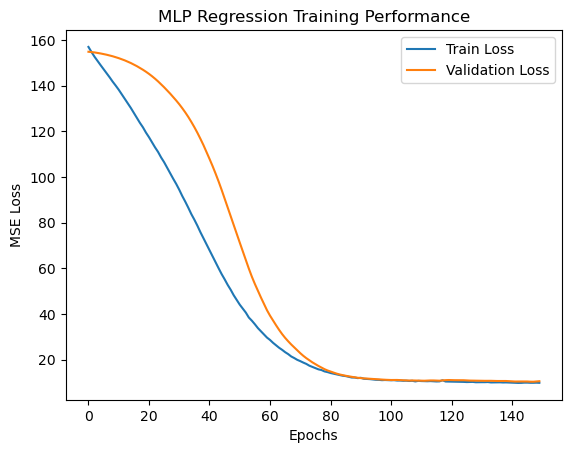

In [187]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("MLP Regression Training Performance")
plt.show()


### Save Trained Model

In [188]:
model_dir = "artifacts"
os.makedirs(model_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(model_dir, "mlp_model_weights.pth"))
print("Model weights saved")


Model weights saved


### Summary

- Loaded preprocessed train/validation/test splits from `processed/*.csv`.
- Separated features from the target (`price`).
- Built a preprocessing pipeline:
  - Standard scaled numeric features.
  - One-hot encoded categorical features.
- Transformed all splits using a `ColumnTransformer` fitted **only on the training set**.
- Converted the transformed features and targets into PyTorch tensors.
- Defined and trained a Multilayer Perceptron (MLP) regression model using MSE loss and Adam optimizer.
- Monitored training and validation loss across epochs to check for over/under-fitting.
- Saved:
  - The preprocessing pipeline → `artifacts/preprocessor.joblib`
  - The trained model weights → `artifacts/mlp_regressor.pth`

The **next notebook (Notebook 3 – Evaluation)** will:

1. Reload `test.csv`, the saved `preprocessor.joblib`, and `mlp_regressor.pth`.
2. Transform the test features and compute regression metrics (MSE, RMSE, possibly R²).
3. Optionally visualize predicted vs actual prices.